# Notebook 07 — Parte IV: Sistemas de recomendación híbridos

## Qué cubre del enunciado (PARTE IV, 4 pts)
Filtrado colaborativo (**item-item**), **content-based** (TF-IDF de reseñas + atributos), **híbrido**, y evaluación rigurosa **Precision@K / Recall@K / NDCG / RMSE / MAE** frente a *baselines* (aleatorio, top-popular). Todo **a mano** (numpy) en `src/recommenders.py`.

## Fundamento teórico (diapositivas en `teoria/`)
- CF item-item, vecinos y similitud — deck «09 - Recomendacion» **págs. 34-41**; Pearson/coseno **27-33** y deck «10» **8, 11**.
- Predictor *baseline* μ+b_u+b_i — deck 09 **pág. 40** · deck 10 **pág. 9**.
- TF-IDF y content-based — deck 09 **págs. 14-21** (TF-IDF 16-17).
- RMSE/MAE — deck 09 **pág. 43** · deck 10 **págs. 4-6**. Cold-start — deck 09 **pág. 42**.
- **NDCG / Precision@K / Recall@K NO están en los decks del curso** → se fundan en definiciones de Recuperación de Información estándar (MMDS cap. 9) que exige el enunciado (honestidad de fuentes, igual que HITS en la Parte II).
- El **híbrido CF+contenido** tampoco está nombrado en los decks (el *blend* de los decks es baseline+vecindario); se funda como práctica estándar + requisito del enunciado.

## Diseño (sin fuga de datos)
Split **temporal**: train ≤2018 · validación 2019 · test 2020-21. Los hiperparámetros se calibran en 2019 y el **test se evalúa una sola vez**. ACS **no** entra al recomendador (se reserva para la auditoría de equidad de la Parte VII).

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append("..")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import recommenders as rec, viz
from src.config import GOLD
viz.aplicar_estilo()

## Paso 1 — Datos e interacciones (split temporal)
Deduplicamos a la primera visita de cada par usuario-restaurante y partimos por tiempo; marcamos las cohortes cold-start (un usuario es *warm* si tiene ≥3 interacciones en train: sin historial el CF no tiene vecinos).

In [2]:
df = rec.cargar_interacciones()
train, val, test = rec.split_temporal(df)
warm_u, warm_i = rec.conjuntos_warm(train)   # warm user = >=3 interacciones
tc = rec.cohortes_cold_start(test, warm_u, warm_i)
print(f"dedup={len(df):,} | train={len(train):,} val={len(val):,} test={len(test):,}")
print(f"usuarios warm={len(warm_u):,} | items warm={len(warm_i):,}")
print(tc.cohorte.value_counts().to_string())

dedup=2,580,540 | train=1,852,788 val=325,873 test=391,237
usuarios warm=150,350 | items warm=25,952
cohorte
cold_user-warm_item    223802
warm_user-warm_item     78173
cold_user-cold_item     60012
warm_user-cold_item     29250


docs/figs/parte4_diseno_temporal_cohortes.png


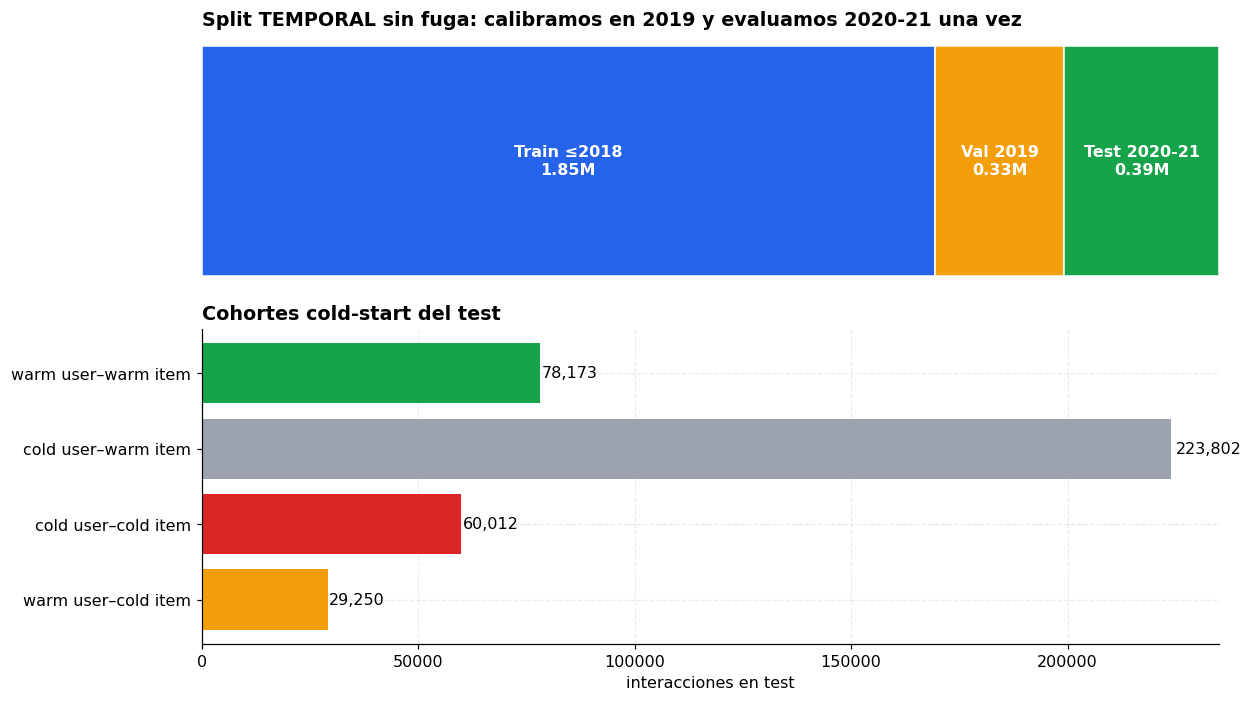

In [3]:
# Figura del diseño temporal y las cohortes cold-start
fig, axes = plt.subplots(2, 1, figsize=(11.5, 6.5), gridspec_kw={"height_ratios": [1, 1.25]})
split_counts = np.array([len(train), len(val), len(test)], dtype=float)
split_labels = ["Train ≤2018", "Val 2019", "Test 2020-21"]
split_colors = [viz.PALETA["azul"], viz.PALETA["naranja"], viz.PALETA["verde"]]
left = 0.0
for count, label, color in zip(split_counts, split_labels, split_colors):
    width = count / split_counts.sum()
    axes[0].barh([0], [width], left=left, color=color, edgecolor="white", height=.62)
    axes[0].text(left + width/2, 0, f"{label}\n{count/1e6:.2f}M", ha="center", va="center",
                 color="white", fontweight="bold")
    left += width
axes[0].set_xlim(0, 1); axes[0].axis("off")
axes[0].set_title("Split TEMPORAL sin fuga: calibramos en 2019 y evaluamos 2020-21 una vez")

cohort_order = ["warm_user-warm_item", "cold_user-warm_item", "cold_user-cold_item", "warm_user-cold_item"]
cohort_labels = ["warm user–warm item", "cold user–warm item", "cold user–cold item", "warm user–cold item"]
cohort_counts = tc.cohorte.value_counts().reindex(cohort_order).fillna(0)
bars = axes[1].barh(cohort_labels, cohort_counts, color=[viz.PALETA["verde"], viz.PALETA["gris"], viz.PALETA["rojo"], viz.PALETA["naranja"]])
for bar, value in zip(bars, cohort_counts):
    axes[1].text(bar.get_width()*1.005, bar.get_y()+bar.get_height()/2, f"{int(value):,}", va="center")
axes[1].invert_yaxis(); axes[1].set_xlabel("interacciones en test")
axes[1].set_title("Cohortes cold-start del test")
print(viz.guardar(fig, "parte4_diseno_temporal_cohortes")); plt.show()


### Lo que encontramos (Paso 1)
Del total deduplicado (2,580,540), el split temporal deja **1.85M** de entrenamiento, 326k de validación y **391k de test**. Hay **150,350 usuarios warm** y 25,952 restaurantes warm; el **94.8%** de las visitas warm ocurren en el mercado habitual del usuario, lo que justifica generar candidatos *in-market*. Las cohortes cold-start (29,250 warm-user/cold-item; 60,012 cold-cold) fijan qué puede resolver cada modelo.

## Paso 2 — Filtrado colaborativo item-item (a mano)
Similitud **Pearson** centrada por ítem con *shrinkage* n/(n+λ) y mínimo de co-calificaciones; predicción `r̂ = baseline + Σ sim·(r−baseline)/Σ|sim|`. Validamos primero en un ejemplo de juguete.

In [4]:
# Validación en ejemplo de juguete (i0,i1 correlacionados; i2 anticorrelacionado)
data={'u0':{'i0':5,'i1':5,'i2':1},'u1':{'i0':4,'i1':4,'i2':2},'u2':{'i0':5,'i1':4,'i2':1},'u3':{'i0':2,'i1':2,'i2':5},'u4':{'i0':1,'i1':1,'i2':4}}
toy=pd.DataFrame([(u,i,s) for u,d in data.items() for i,s in d.items()],columns=['user_id','business_id','stars'])
Mt=rec.matriz_train(toy); nb=rec.similitud_item_item(Mt,min_coratings=2,shrink=0.0,topk=2)
def _sim(a,b):
    ia,ib=Mt['i2x'][a],Mt['i2x'][b]; A,B=nb['indptr'][ia],nb['indptr'][ia+1]
    return next((float(s) for v,s in zip(nb['vecino'][A:B],nb['sim'][A:B]) if v==ib),None)
print('sim(i0,i1)=',round(_sim('i0','i1'),3),'(~0.97) | sim(i0,i2)=',round(_sim('i0','i2'),3),'(~-0.92)')

sim(i0,i1)= 0.972 (~0.97) | sim(i0,i2)= -0.924 (~-0.92)


In [5]:
# CF sobre datos reales
M = rec.matriz_train(train)
mu, b_u, b_i = rec.baseline(M)
nbrs = rec.similitud_item_item(M, min_coratings=5, shrink=50.0, topk=40, cap_user=50)
deg=np.diff(nbrs['indptr']); print(f"items con vecinos: {(deg>0).sum():,}/{M['n_items']:,} | vecinos medios={deg[deg>0].mean():.1f}")

items con vecinos: 11,234/25,952 | vecinos medios=17.4


### Lo que encontramos (Paso 2)
El CF a mano reproduce las similitudes calculadas a mano (0.97 / −0.92). En real, **11,234/25,952** restaurantes obtienen vecinos fiables (≥5 co-reseñadores); el resto cae a *baseline*/contenido.

## Paso 3 — Content-based: TF-IDF de reseñas + categorías (a mano)
Agregamos las reseñas ≤2018 por restaurante (tope por ítem para acotar memoria) y construimos TF-IDF (tf log × idf, L2). Verificamos que capture cocina.

In [6]:
# Documentos por ítem en streaming (memoria acotada)
import datetime as dt, pyarrow.dataset as dsa, pyarrow as pa
scan=dsa.dataset(str(GOLD/'resenas_universo.parquet')).scanner(columns=['business_id','date','text'], filter=dsa.field('date')<pa.scalar(dt.datetime(2019,1,1)))
kept={}
for bt in scan.to_batches():
    for b,x in zip(bt.column('business_id').to_pylist(), bt.column('text').to_pylist()):
        l=kept.get(b)
        if l is None: kept[b]=[x[:250]]
        elif len(l)<15: l.append(x[:250])
neg=pd.read_parquet(GOLD/'negocios_universo.parquet',columns=['business_id','name','categories'])
cat={b:['cat_'+str(c).lower().replace(' ','_').replace('&','and').replace('/','_') for c in (list(cs) if cs is not None else [])] for b,cs in zip(neg.business_id,neg.categories)}
bids=list(kept); docs=[" ".join(v) for v in kept.values()]
tfidf = rec.construir_tfidf(bids, docs, extra_tokens=cat, max_vocab=5000, min_df=10)
print(f"TF-IDF: {len(bids):,} items x vocab {tfidf['n_vocab']}")
idx={b:i for i,b in enumerate(tfidf['business_ids'])}
fb=lambda n: neg[neg.name.str.contains(n,case=False,na=False)].business_id.iloc[0]
print('sim(Pat\'s,Geno\'s)=',round(rec.sim_contenido(tfidf,idx[fb("Pat's King")],idx[fb("Geno's")]),3),'| sim(Pat\'s,Zahav)=',round(rec.sim_contenido(tfidf,idx[fb("Pat's King")],idx[fb('Zahav')]),3))

TF-IDF: 25,952 items x vocab 5000
sim(Pat's,Geno's)= 0.33 | sim(Pat's,Zahav)= 0.045


### Lo que encontramos (Paso 3)
El TF-IDF captura **cocina**: dos cheesesteaks (Pat's–Geno's ≈ 0.33) son ~7× más similares que un cheesesteak y un restaurante de autor (Pat's–Zahav ≈ 0.05).

## Paso 4 — Evaluación rigurosa (sin fuga)
Dos tracks: **predicción de rating** (RMSE/MAE sobre warm-warm) y **ranking** (Precision@K/Recall@K/NDCG@K con negativos muestreados *in-market*, IC bootstrap). Calibramos el híbrido en validación. Reportamos también **cobertura** y **novedad** para exponer el sesgo de popularidad.

> **Hallazgos clave:** (1) en *rating* el **baseline gana** (RMSE 1.24) — el CF brilla en ranking, no en RMSE; (2) para *ranking* el CF debe puntuarse por **suma de similitudes**, no por predicción (NDCG 0.20→0.52); (3) el **CF item-item gana** el ranking (NDCG 0.49, IC sin solaparse) con alta cobertura, mientras el **top-popular** es preciso pero recomienda siempre lo mismo (cobertura 13%).

In [7]:
# (track ranking) candidatos in-market + evaluación de modelos
uindptr, uitems, uratings = rec.usuario_csr(M)
u2x, i2x = M["u2x"], M["i2x"]
cu = pd.Series(M["ux"]).value_counts()
warm = set(cu[cu >= 3].index)
neg2=pd.read_parquet(GOLD/"negocios_universo.parquet",columns=["business_id","metro"]); b2m=dict(zip(neg2.business_id,neg2.metro))
i_metro=np.array([b2m.get(b,"?") for b in M["items"]]); metro_items={m:np.where(i_metro==m)[0] for m in pd.unique(i_metro)}
tb2x={b:i for i,b in enumerate(tfidf["business_ids"])}; cf2tf=np.array([tb2x.get(b,-1) for b in M["items"]])
pop=rec.popularidad(M); nov_item=-np.log2(pop/pop.sum()+1e-12)
def cands(split,n,seed):
    r=np.random.default_rng(seed); s=split[split.user_id.isin(u2x)&split.business_id.isin(i2x)].copy()
    s["uidx"]=s.user_id.map(u2x); s["iidx"]=s.business_id.map(i2x); s=s[s.uidx.isin(warm)&(s.stars>=4)]
    posu=s.groupby("uidx")["iidx"].apply(lambda x:list(set(x))); us=list(posu.index); r.shuffle(us); out=[]
    for u in us:
        a,b=uindptr[u],uindptr[u+1]; seen=set(uitems[a:b].tolist()); pos=[i for i in posu[u] if i not in seen]
        if not pos: continue
        hm=pd.Series(i_metro[uitems[a:b]]).mode(); hm=hm.iloc[0] if len(hm) else i_metro[pos[0]]
        nc=[i for i in r.choice(metro_items[hm],size=min(99,len(metro_items[hm])),replace=False).tolist() if i not in seen and i not in pos][:99]
        out.append((u,np.array(pos+nc),np.array([1]*len(pos)+[0]*len(nc)),uitems[a:b],uratings[a:b]))
        if len(out)>=n: break
    return out
zn=lambda x:(x-x.mean())/(x.std()+1e-9)
def s_cf(u,c,ui,ur):
    liked=set(ui[ur>=4].tolist()); o=np.zeros(len(c))
    for k,i in enumerate(c):
        A,B=nbrs["indptr"][i],nbrs["indptr"][i+1]
        o[k]=sum(sv for vv,sv in zip(nbrs["vecino"][A:B].tolist(),nbrs["sim"][A:B].tolist()) if vv in liked)
    return o
def s_con(u,c,ui,ur):
    tfi=cf2tf[ui[ur>=4]]; tfi=tfi[tfi>=0]
    if len(tfi)==0: return np.zeros(len(c))
    p=rec.perfil_contenido(tfi,np.ones(len(tfi)),tfidf); cc=cf2tf[c]; o=np.zeros(len(c)); m=cc>=0; o[m]=rec.score_contenido(p,tfidf,cc[m]); return o


docs/figs/parte4_curva_hibrido.png


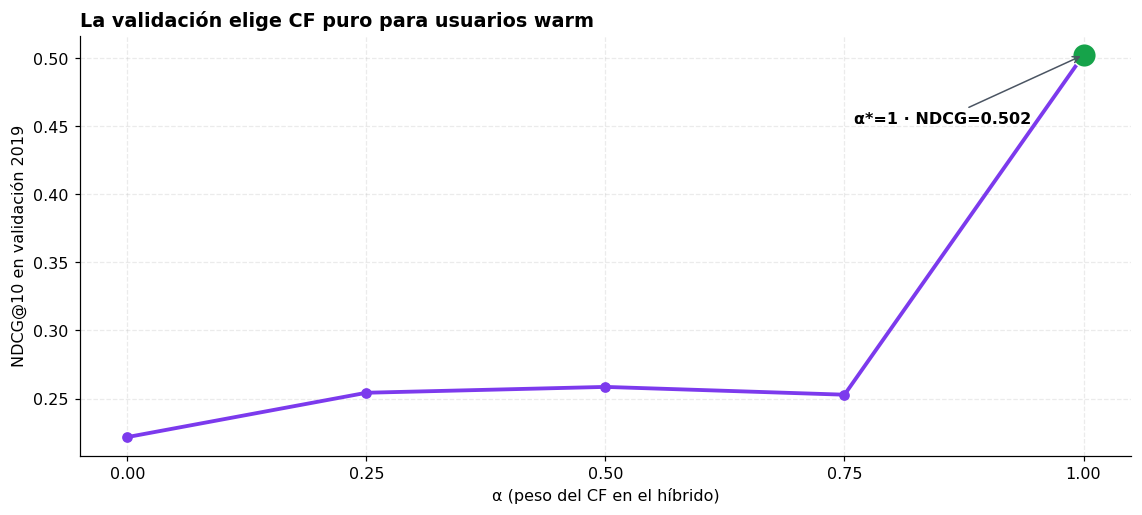

In [8]:
# Calibración real del híbrido en VALIDACIÓN (2019), sin tocar test
valc = cands(val, 1000, 41)
val_cache = []
for u, candidates, rel, user_items, user_ratings in valc:
    val_cache.append((u, candidates, rel, user_items, user_ratings,
                      s_cf(u, candidates, user_items, user_ratings),
                      s_con(u, candidates, user_items, user_ratings)))

alphas = np.array([0.0, 0.25, 0.50, 0.75, 1.0])
ndcg_alpha = []
for alpha in alphas:
    scores = []
    for u, candidates, rel, user_items, user_ratings, cf_score, content_score in val_cache:
        blended = alpha*zn(cf_score) + (1-alpha)*zn(content_score)
        scores.append(rec.ndcg_at_k(rel[np.argsort(-blended)], 10))
    ndcg_alpha.append(float(np.mean(scores)))
curva_hibrido = pd.DataFrame({"alpha_cf": alphas, "NDCG_at_10_validacion": ndcg_alpha})
curva_hibrido.to_parquet(GOLD/"curva_hibrido_validacion.parquet", index=False)

# Control metodológico: ranking por rating predicho vs suma de similitudes
ndcg_rating, ndcg_similarity = [], []
for u, candidates, rel, user_items, user_ratings, cf_score, _ in val_cache:
    rating_score = np.array([rec.predecir(user_items, user_ratings, mu, b_u[u], b_i, nbrs, int(i)) for i in candidates])
    ndcg_rating.append(rec.ndcg_at_k(rel[np.argsort(-rating_score)], 10))
    ndcg_similarity.append(rec.ndcg_at_k(rel[np.argsort(-cf_score)], 10))
comparativa_score = pd.DataFrame({
    "score": ["predicción de rating", "suma de similitudes"],
    "NDCG_at_10_validacion": [np.mean(ndcg_rating), np.mean(ndcg_similarity)],
})
comparativa_score.to_parquet(GOLD/"comparativa_score_cf_validacion.parquet", index=False)

fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.plot(alphas, ndcg_alpha, marker="o", lw=2.5, color=viz.PALETA["morado"])
best = int(np.argmax(ndcg_alpha))
best_alpha = float(alphas[best])
ax.scatter(alphas[best], ndcg_alpha[best], s=240, color=viz.PALETA["verde"], edgecolor="white", zorder=3)
ax.annotate(f"α*={alphas[best]:.2g} · NDCG={ndcg_alpha[best]:.3f}",
            (alphas[best], ndcg_alpha[best]), xytext=(-150, -45), textcoords="offset points",
            arrowprops={"arrowstyle":"->", "color":viz.PALETA["gris_oscuro"]}, fontweight="bold")
ax.set_xlabel("α (peso del CF en el híbrido)"); ax.set_ylabel("NDCG@10 en validación 2019")
ax.set_xticks(alphas); ax.set_title("La validación elige CF puro para usuarios warm")
print(viz.guardar(fig, "parte4_curva_hibrido")); plt.show()

In [9]:
# (track rating) RMSE/MAE sobre warm-warm de test
uindptr,uitems,uratings = rec.usuario_csr(M); u2x=M["u2x"]; i2x=M["i2x"]
cu=pd.Series(M["ux"]).value_counts(); warm=set(cu[cu>=3].index)
tt=test[test.user_id.isin(u2x)&test.business_id.isin(i2x)].copy()
tt["uidx"]=tt.user_id.map(u2x); tt["iidx"]=tt.business_id.map(i2x); tt=tt[tt.uidx.isin(warm)]
pm=[];pb=[];pc=[];tr=tt.stars.to_numpy(float)
for u,i in zip(tt.uidx.to_numpy(),tt.iidx.to_numpy()):
    a,b=uindptr[u],uindptr[u+1]; base=mu+b_u[u]+b_i[i]
    pm.append(mu); pb.append(base); pc.append(rec.predecir(uitems[a:b],uratings[a:b],mu,b_u[u],b_i,nbrs,i))
clip=lambda x:np.clip(x,1,5)
for nm,p in [("media μ",pm),("baseline",pb),("CF",clip(pc))]:
    print(f"  {nm:9s} RMSE={rec.rmse(p,tr):.4f} MAE={rec.mae(p,tr):.4f}")

  media μ   RMSE=1.3815 MAE=1.1662
  baseline  RMSE=1.2411 MAE=0.9972
  CF        RMSE=1.3050 MAE=1.0253


In [10]:
# Evaluación ÚNICA sobre test, después de fijar α en validación
mods={"Random":lambda u,c,ui,ur:np.random.default_rng(u).random(len(c)),"Top-popular":lambda u,c,ui,ur:pop[c],
      "CF item-item":s_cf,"Content TF-IDF":s_con,"Híbrido α=.5 (ablación)":lambda u,c,ui,ur:0.5*zn(s_cf(u,c,ui,ur))+0.5*zn(s_con(u,c,ui,ur))}
testc=cands(test,1500,42); res={}
for nm,fn in mods.items():
    Ps=[];Rs=[];Ns=[];rd=[]
    for u,c,rel,ui,ur in testc:
        o=np.argsort(-fn(u,c,ui,ur)); rr=rel[o]; Ps.append(rec.precision_at_k(rr,10)); Rs.append(rec.recall_at_k(rr,10,rel.sum())); Ns.append(rec.ndcg_at_k(rr,10)); rd+=c[o[:10]].tolist()
    Ns=np.array(Ns); rng=np.random.default_rng(0); bs=[Ns[rng.integers(0,len(Ns),len(Ns))].mean() for _ in range(500)]
    res[nm]=dict(P=np.mean(Ps),R=np.mean(Rs),N=Ns.mean(),lo=np.percentile(bs,2.5),hi=np.percentile(bs,97.5),cov=len(set(rd))/M["n_items"],nov=float(np.mean(nov_item[np.array(rd)])))
print(f"{'modelo':28s}{'P@10':>8}{'R@10':>8}{'NDCG@10':>9}{'cobert':>9}{'noved':>7}")
for nm,d in sorted(res.items(),key=lambda x:-x[1]["N"]):
    print(f"{nm:28s}{d['P']:8.3f}{d['R']:8.3f}{d['N']:9.3f}{d['cov']*100:8.1f}%{d['nov']:7.2f}")

modelo                          P@10    R@10  NDCG@10   cobert  noved
CF item-item                   0.110   0.574    0.491    39.3%  14.91
Top-popular                    0.103   0.386    0.259    13.0%  12.51
Híbrido α=.5 (ablación)        0.089   0.331    0.250    33.9%  14.30
Content TF-IDF                 0.076   0.297    0.205    33.7%  14.67
Random                         0.026   0.088    0.057    43.8%  15.92


docs/figs/parte4_ajuste_score_y_rating.png


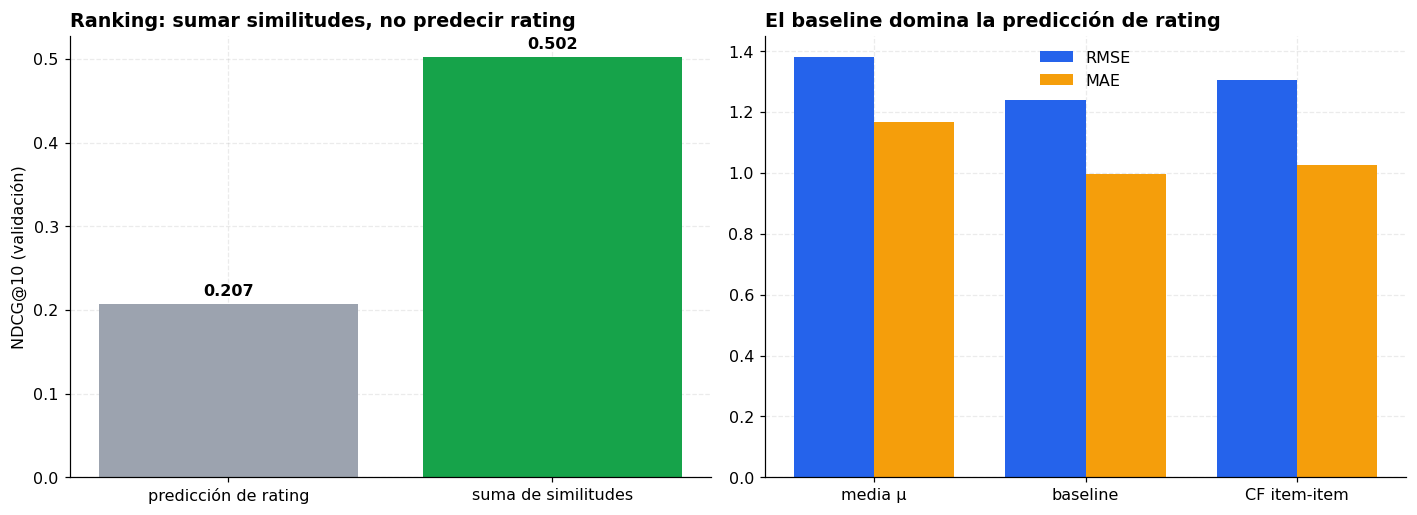

,alpha_cf,NDCG_at_10_validacion
0,0.00,0.222
1,0.25,0.254
2,0.50,0.259
3,0.75,0.253
4,1.00,0.502


,score,NDCG_at_10_validacion
0,predicción de rating,0.207
1,suma de similitudes,0.502


In [11]:
# Comparación de objetivos, después de evaluar rating en test
rating_metrics = pd.DataFrame([
    ["media μ", rec.rmse(pm, tr), rec.mae(pm, tr)],
    ["baseline", rec.rmse(pb, tr), rec.mae(pb, tr)],
    ["CF item-item", rec.rmse(clip(pc), tr), rec.mae(clip(pc), tr)],
], columns=["modelo", "RMSE", "MAE"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
bars = axes[0].bar(comparativa_score.score, comparativa_score.NDCG_at_10_validacion,
                   color=[viz.PALETA["gris"], viz.PALETA["verde"]])
for bar, value in zip(bars, comparativa_score.NDCG_at_10_validacion):
    axes[0].text(bar.get_x()+bar.get_width()/2, value+.01, f"{value:.3f}", ha="center", fontweight="bold")
axes[0].set_ylabel("NDCG@10 (validación)")
axes[0].set_title("Ranking: sumar similitudes, no predecir rating")
x = np.arange(len(rating_metrics)); width=.38
axes[1].bar(x-width/2, rating_metrics.RMSE, width, label="RMSE", color=viz.PALETA["azul"])
axes[1].bar(x+width/2, rating_metrics.MAE, width, label="MAE", color=viz.PALETA["naranja"])
axes[1].set_xticks(x); axes[1].set_xticklabels(rating_metrics.modelo); axes[1].legend()
axes[1].set_title("El baseline domina la predicción de rating")
print(viz.guardar(fig, "parte4_ajuste_score_y_rating")); plt.show()
display(curva_hibrido.round(3)); display(comparativa_score.round(3))


### Lo que encontramos (Paso 4)
**CF item-item gana** (NDCG@10 ≈ 0.49, IC bootstrap sin solaparse) con cobertura 39%. **Top-popular** es 2º en accuracy pero su **cobertura cae a 13%** y es lo menos novedoso — preciso a costa de recomendar siempre lo mismo (sesgo de popularidad, insumo de la Parte VII). El **híbrido ponderado** no supera al CF en usuarios *warm*: validación elige α=1, por lo que el modelo seleccionado coincide con CF. El blend 50/50 se conserva solo como **ablación**; una conmutación explícita a contenido para *cold-start* queda como extensión, no como resultado medido.

## Paso 5 — Figuras para el informe y persistencia
Generamos las figuras `docs/figs/parte4_*` (estilo `src.viz`) y guardamos `metricas_recomendacion` y `recomendaciones_ejemplo` en `data/gold/`. Todas las figuras y tablas se regeneran en las celdas siguientes.

docs/figs/parte4_comparativa_metricas.png


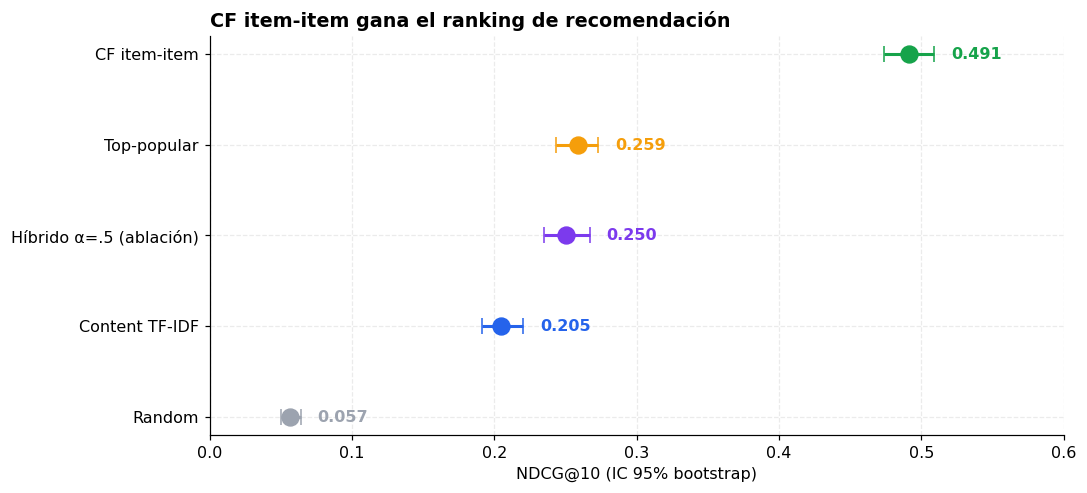

docs/figs/parte4_accuracy_vs_diversidad.png


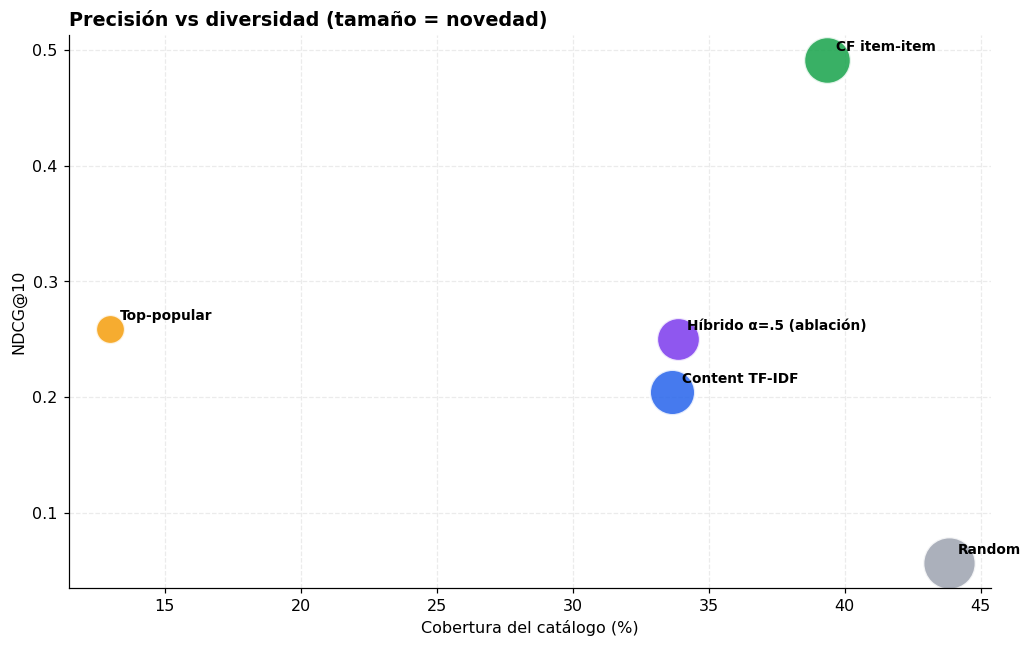

In [12]:
# Comparativa de métricas con IC (figura principal)
import matplotlib.pyplot as plt; P=viz.PALETA
col={"CF item-item":P["verde"],"Top-popular":P["naranja"],"Content TF-IDF":P["azul"],"Híbrido α=.5 (ablación)":P["morado"],"Random":P["gris"]}
order=sorted(res,key=lambda m:res[m]["N"]); fig,ax=plt.subplots(figsize=(10,4.6))
for y,m in enumerate(order):
    d=res[m]; ax.errorbar(d["N"],y,xerr=[[d["N"]-d["lo"]],[d["hi"]-d["N"]]],fmt="o",ms=11,color=col[m],capsize=5,lw=2); ax.text(d["hi"]+.012,y,f"{d['N']:.3f}",va="center",fontweight="bold",color=col[m])
ax.set_yticks(range(len(order))); ax.set_yticklabels(order); ax.set_xlabel("NDCG@10 (IC 95% bootstrap)"); ax.set_xlim(0,0.6)
ax.set_title("CF item-item gana el ranking de recomendación",fontweight="bold"); print(viz.guardar(fig,"parte4_comparativa_metricas")); plt.show()
# Frontera precisión vs diversidad
fig,ax=plt.subplots(figsize=(9.5,6))
for m in res:
    d=res[m]; ax.scatter(d["cov"]*100,d["N"],s=(d["nov"]-11)*240,color=col[m],alpha=.85,edgecolors="white",lw=1.5); ax.annotate(m,(d["cov"]*100,d["N"]),xytext=(6,6),textcoords="offset points",fontweight="bold",fontsize=9)
ax.set_xlabel("Cobertura del catálogo (%)"); ax.set_ylabel("NDCG@10"); ax.set_title("Precisión vs diversidad (tamaño = novedad)",fontweight="bold"); print(viz.guardar(fig,"parte4_accuracy_vs_diversidad")); plt.show()

docs/figs/parte4_mapa_recomendacion.png


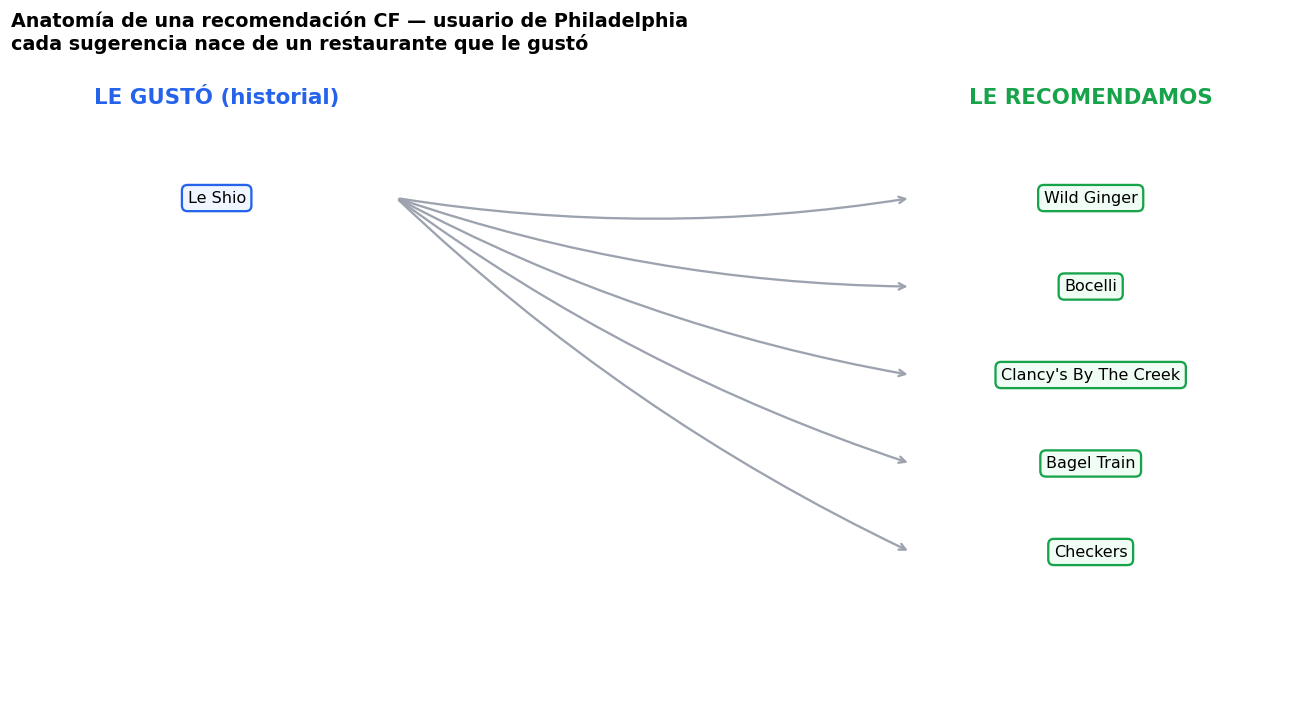

recomendaciones_ejemplo.parquet: 150 filas


In [13]:
# Ejemplos explicables: cada recomendación conserva el vecino que más contribuyó
name_by_business = dict(zip(neg.business_id, neg.name))
example_rows = []
for u, candidates, rel, user_items, user_ratings in testc[:30]:
    score = s_cf(u, candidates, user_items, user_ratings)
    liked = set(user_items[user_ratings >= 4].tolist())
    for rank_pos, item in enumerate(candidates[np.argsort(-score)[:5]], 1):
        a, b = nbrs["indptr"][item], nbrs["indptr"][item+1]
        contributions = [(float(sim), int(neighbor)) for neighbor, sim in zip(nbrs["vecino"][a:b], nbrs["sim"][a:b]) if int(neighbor) in liked]
        reason_idx = max(contributions, default=(0.0, next(iter(liked), int(item))))[1]
        business_id = M["items"][item]
        reason_id = M["items"][reason_idx]
        example_rows.append({
            "user_idx": int(u), "rank": rank_pos, "business_id": business_id,
            "recomendado": name_by_business.get(business_id, business_id),
            "score_cf": float(score[np.where(candidates == item)[0][0]]),
            "porque_le_gusto": name_by_business.get(reason_id, reason_id),
            "mercado": b2m.get(business_id, "?"),
        })
recomendaciones_ejemplo = pd.DataFrame(example_rows)
recomendaciones_ejemplo.to_parquet(GOLD/"recomendaciones_ejemplo.parquet", index=False)

# Mapa explicativo para un usuario con cinco recomendaciones
market_group = recomendaciones_ejemplo[recomendaciones_ejemplo.mercado == "Philadelphia"]
selected_user = int(market_group.user_idx.iloc[0]) if len(market_group) else int(recomendaciones_ejemplo.user_idx.iloc[0])
example = recomendaciones_ejemplo[recomendaciones_ejemplo.user_idx == selected_user].sort_values("rank").head(5)
reasons = list(dict.fromkeys(example.porque_le_gusto.tolist()))
left_y = {name: y for name, y in zip(reasons, np.linspace(.78, .22, len(reasons)))}
right_y = np.linspace(.78, .22, len(example))
fig, ax = plt.subplots(figsize=(12, 6.5)); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
ax.text(.16,.93,"LE GUSTÓ (historial)",ha="center",color=viz.PALETA["azul"],fontweight="bold",fontsize=14)
ax.text(.84,.93,"LE RECOMENDAMOS",ha="center",color=viz.PALETA["verde"],fontweight="bold",fontsize=14)
for name, y in left_y.items():
    ax.text(.16,y,name,ha="center",va="center",bbox={"boxstyle":"round,pad=.35","fc":"#eff6ff","ec":viz.PALETA["azul"],"lw":1.5})
for (_, row), y in zip(example.iterrows(), right_y):
    ax.text(.84,y,row.recomendado,ha="center",va="center",bbox={"boxstyle":"round,pad=.35","fc":"#f0fdf4","ec":viz.PALETA["verde"],"lw":1.5})
    ax.annotate("", xy=(.70,y), xytext=(.30,left_y[row.porque_le_gusto]),
                arrowprops={"arrowstyle":"->","color":"#9ca3af","lw":1.5,"connectionstyle":"arc3,rad=.08"})
market = example.mercado.iloc[0]
ax.set_title(f"Anatomía de una recomendación CF — usuario de {market}\ncada sugerencia nace de un restaurante que le gustó")
print(viz.guardar(fig, "parte4_mapa_recomendacion")); plt.show()
print(f"recomendaciones_ejemplo.parquet: {len(recomendaciones_ejemplo)} filas")


In [14]:
# Persistir métricas en gold
rat={"media μ":(rec.rmse(pm,tr),rec.mae(pm,tr)),"baseline":(rec.rmse(pb,tr),rec.mae(pb,tr)),"CF item-item":(rec.rmse(clip(pc),tr),rec.mae(clip(pc),tr))}
rows=[dict(modelo=m,P_at_10=d["P"],R_at_10=d["R"],NDCG_at_10=d["N"],ndcg_ci_lo=d["lo"],ndcg_ci_hi=d["hi"],cobertura=d["cov"],novedad=d["nov"],RMSE=rat.get(m,(np.nan,np.nan))[0],MAE=rat.get(m,(np.nan,np.nan))[1]) for m,d in res.items()]
pd.DataFrame(rows).to_parquet(GOLD/"metricas_recomendacion.parquet",index=False)
print("metricas_recomendacion.parquet guardado")

metricas_recomendacion.parquet guardado


## Resumen del notebook
**Parte IV cerrada.** Recomendador híbrido a mano sobre split temporal sin fuga: CF item-item (Pearson+shrinkage), content-based TF-IDF y blend, evaluados con Precision@K/Recall@K/NDCG/RMSE/MAE + cobertura/novedad e IC bootstrap, contra baselines aleatorio y top-popular. **El CF item-item es el mejor en ranking** (NDCG 0.49) y, a diferencia del top-popular, mantiene alta cobertura; el baseline domina la predicción de rating. Resultados y 6 figuras persistidos para el informe y la Parte VII (equidad/exposición).